# Theta phase precession in hippocampal CA1 place cells

**Dataset:** [DANDI:000044](https://dandiarchive.org/dandiset/000044) — Grosmark & Buzsáki
(2016), *Diversity in neural firing dynamics supports both rigid and learned hippocampal
sequences*, also distributed as `hc-11` on CRCNS. Four rats (Achilles, Cicero, Gatsby,
Buddy) ran back and forth on a linear track for water reward while 128-site silicon probes
recorded from dorsal CA1 of both hemispheres. Each NWB file contains spike-sorted units
with a putative excitatory/inhibitory label, a 1250 Hz local field potential on all 128
channels, and video-tracked position that has been linearized onto the track.

**The phenomenon.** A CA1 place cell fires when the animal occupies a restricted part of
the environment, its place field. O'Keefe and Recce (1993) showed that the *timing* of
those spikes relative to the ongoing 6-12 Hz theta rhythm carries additional information:
on entering the field a cell fires near the peak of the theta cycle, and with each
successive cycle it fires a little earlier, so that by the time the animal leaves the field
the spikes have shifted through roughly a full theta cycle. The spatial position of the
animal is therefore encoded twice over, once by which cells fire and once by when in the
theta cycle they fire.

**What this notebook does.** It streams the NWB files from the DANDI S3 bucket (no full
downloads), reconstructs the animal's laps, extracts theta phase from the LFP channel with
the strongest theta, identifies direction-specific place fields with Pynapple, and fits a
circular-linear regression of spike theta phase against normalised within-field position
for every field. The regression, the correlation coefficient and the permutation test are
those of Kempter, Leibold, Buzsáki, Diba and Schmidt (2012).

**Result.** Across 5 linear-track sessions from 4 rats, 96 place fields met criteria; 85%
had a negative phase-position slope, 73% reached significance against a within-field
shuffle, and 66% were both significant and negative. The median slope was about -225
degrees per field traversal, i.e. close to the two-thirds of a theta cycle that the
original reports describe.

## Setup

In [1]:
import warnings

import h5py
import lindi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
from matplotlib.gridspec import GridSpec
from pynwb import NWBHDF5IO
from scipy.ndimage import gaussian_filter1d
from scipy.signal import butter, filtfilt, hilbert, welch
from scipy.stats import binomtest, wilcoxon
from IPython.display import Image, display
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", message="timestamps are not sorted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "font.size": 10})

DANDISET = "000044"

# All eight assets in the dandiset, as session name -> DANDI asset id.
SESSIONS = {
    "Achilles-10252013": "5349c68b-c0a7-46c0-9900-cda050722fa4",
    "Achilles-11012013": "8855c8cc-9d8b-4d5b-8ef0-fe87916f839a",
    "Cicero-09012014": "3cc5b7b3-02e2-490a-9f19-d20670355084",
    "Cicero-09102014": "f61dfe09-3db2-464a-b386-2e828b2e7276",
    "Cicero-09172014": "e381ebb3-128e-4f3f-9517-11277d7aed9b",
    "Gatsby-08022013": "31ea0aab-4777-424e-9a93-9605b2bdcc29",
    "Gatsby-08282013": "f7687af7-3bc9-4d20-8d88-ef293d2a3381",
    "Buddy-06272013": "82714afb-724f-4e2b-b102-c9c47b5cba73",
}

# Three of the sessions used a circular maze whose linearization wraps around and
# does not decompose into clean unidirectional traversals with the simple rule used
# below, so the analysis is restricted to the five linear-track sessions.
LINEAR_SESSIONS = ["Achilles-10252013", "Cicero-09012014", "Cicero-09172014",
                   "Gatsby-08022013", "Buddy-06272013"]
EXAMPLE_SESSION = "Achilles-10252013"

LFP_RATE = 1250.0          # Hz, sampling rate of the stored LFP
THETA_BAND = (6.0, 12.0)   # Hz
SPEED_THRESH = 0.10        # m/s
MIN_RUN_DUR = 0.5          # s, shortest acceptable lap
MIN_RUN_FRAC = 0.6         # a lap must cover this fraction of the track
BIN_SIZE = 0.04            # m, spatial bin for the place field maps
MIN_PEAK_RATE = 1.0        # Hz
MIN_SPATIAL_INFO = 0.5     # bits/spike
MIN_FIELD_SPIKES = 50      # in-field spikes needed to fit a regression
EDGE_FRAC = 0.09           # keep field peaks away from the track ends
N_SHUFFLE = 500


def open_session(session_name, cache=lindi.LocalCache()):
    """Stream one hc-11 session from DANDI through LINDI. Returns (h5-like file, NWBFile)."""
    url = f"https://lindi.neurosift.org/dandi/dandisets/{DANDISET}/assets/{SESSIONS[session_name]}/nwb.lindi.json"
    f = lindi.LindiH5pyFile.from_lindi_file(url, local_cache=cache)
    return f, NWBHDF5IO(file=f, mode="r").read()

## What is inside one file

Streaming means the 8.7 GB file is never downloaded; LINDI fetches only the byte ranges
that are actually read, and the local cache keeps them for subsequent cells.

In [2]:
f, nwbfile = open_session(EXAMPLE_SESSION)
print(nwbfile.session_id, "|", nwbfile.session_description)
print("subject:", nwbfile.subject.subject_id, "|", nwbfile.subject.species)
print("lab:", nwbfile.lab, nwbfile.institution)
print()
print("epochs:")
for lab, s, e in zip(f["intervals/epochs/label"][:], f["intervals/epochs/start_time"][:],
                     f["intervals/epochs/stop_time"][:]):
    lab = lab.decode() if isinstance(lab, bytes) else lab
    print(f"  {lab:12s} {s:9.1f} - {e:9.1f} s")
print()
print("LFP:", f["processing/ecephys/LFP/LFP/data"].shape, "samples x channels @",
      f["processing/ecephys/LFP/LFP/starting_time"].attrs["rate"], "Hz")
print("units:", f["units/id"].shape[0])
print("behaviour:", list(f["processing/behavior"].keys()))

Achilles_10252013 | This data set is composed of eight bilateral silicon-probe multi-cellular electrophysiological 
subject: Achilles | Rattus norvegicus domestica - Long Evans
lab: Buzsaki NYU

epochs:
  PREEpoch           0.0 -   18079.5 s
  MazeEpoch      18079.5 -   20147.0 s
  POSTEpoch      20147.0 -   34861.1 s

LFP: (43576379, 128) samples x channels @ 1250.0 Hz
units: 137
behaviour: ['1.6mLinearMazeLinearizedPosition', '1.6mLinearMazePosition', 'states']


## Behaviour: reconstructing the laps

Two properties of these files need care.

The `SpatialSeries` for position stores the sampling *period* (0.0256 s, i.e. 39.06 Hz) in
the field named `rate`. Reading it as a rate would stretch the behavioural timeline by a
factor of about 1500 and destroy any alignment with the spikes, so the timestamps are
rebuilt explicitly from `starting_time` and the period.

The linearized position is NaN whenever the animal is not traversing the track (sitting at
a reward port, for instance). That is convenient rather than a problem: each contiguous
block of non-NaN samples is exactly one traversal, so laps can be delimited by the NaN
gaps and then filtered for duration, distance covered and monotonicity.

In [3]:
def load_position(f):
    """Linearized position (m) as a Pynapple Tsd, with the sampling-period quirk handled."""
    beh = f["processing/behavior"]
    key = [k for k in beh.keys() if k.endswith("LinearizedPosition")][0]
    grp = beh[key]
    grp = grp[list(grp.keys())[0]]
    period = float(grp["starting_time"].attrs["rate"])  # actually the period
    t0 = float(grp["starting_time"][()])
    data = np.asarray(grp["data"][:]).squeeze()
    t = t0 + np.arange(data.size) * period
    track_len = float(np.ceil(np.nanmax(data) * 10) / 10)
    return nap.Tsd(t=t, d=data), 1.0 / period, track_len, key


def maze_epoch(f):
    ep = f["intervals/epochs"]
    labels = [x.decode() if isinstance(x, bytes) else str(x) for x in ep["label"][:]]
    i = labels.index("MazeEpoch")
    return nap.IntervalSet(start=ep["start_time"][i], end=ep["stop_time"][i])


def smooth(x, n):
    k = np.ones(n) / n
    return np.convolve(np.pad(x, n, mode="edge"), k, mode="same")[n:-n]


def valid_segments(pos):
    """Index ranges [start, stop) of contiguous non-NaN position samples."""
    good = ~np.isnan(pos.values)
    edges = np.diff(good.astype(int))
    s = np.where(edges == 1)[0] + 1
    e = np.where(edges == -1)[0] + 1
    if good[0]:
        s = np.r_[0, s]
    if good[-1]:
        e = np.r_[e, good.size]
    return list(zip(s, e))


def compute_speed(pos, fs):
    """Signed velocity and absolute speed (m/s), computed within valid segments."""
    v = np.full(pos.values.shape, np.nan)
    for s, e in valid_segments(pos):
        if e - s < 5:
            continue
        d = smooth(pos.values[s:e], 5)
        v[s:e] = smooth(np.gradient(d, 1.0 / fs), 5)
    return nap.Tsd(t=pos.times(), d=v), nap.Tsd(t=pos.times(), d=np.abs(v))


def find_runs(pos, vel, fs, track_len):
    """Split the maze epoch into unidirectional traversals.

    Returns (runs_right, runs_left); "right" means increasing linearized position.
    """
    t = pos.times()
    keep = {"right": [], "left": []}
    for s, e in valid_segments(pos):
        if (e - s) / fs < MIN_RUN_DUR:
            continue
        disp = pos.values[e - 1] - pos.values[s]
        if abs(disp) < MIN_RUN_FRAC * track_len:
            continue
        sign = np.sign(disp)
        if np.mean(sign * vel.values[s:e] > 0) < 0.8:
            continue
        keep["right" if sign > 0 else "left"].append((t[s], t[e - 1]))
    return tuple(nap.IntervalSet(start=np.array(keep[k])[:, 0], end=np.array(keep[k])[:, 1])
                 for k in ("right", "left"))


pos, fs_pos, track_len, maze_name = load_position(f)
vel, speed = compute_speed(pos, fs_pos)
runs_r, runs_l = find_runs(pos, vel, fs_pos, track_len)
maze = maze_epoch(f)

print(f"{maze_name}: track length {track_len:.1f} m, position sampled at {fs_pos:.2f} Hz")
print(f"{np.isnan(pos.values).sum()} of {len(pos)} position samples are NaN "
      "(animal not traversing the track)")
print(f"laps: {len(runs_r)} rightward ({runs_r.tot_length():.0f} s), "
      f"{len(runs_l)} leftward ({runs_l.tot_length():.0f} s)")
print(f"peak speed {np.nanmax(np.abs(vel.values)):.2f} m/s")

1.6mLinearMazeLinearizedPosition: track length 1.6 m, position sampled at 39.06 Hz
70426 of 80762 position samples are NaN (animal not traversing the track)
laps: 39 rightward (106 s), 42 leftward (102 s)
peak speed 1.25 m/s


### Figure 1: behaviour and spiking

A first look at the raw streams, to confirm that laps are being detected sensibly and that
the spike times line up with the behavioural epoch.

137 units: {'excitatory': 120, 'inhibitory': 17}
locations: {'rCA1': 72, 'lCA1': 65}


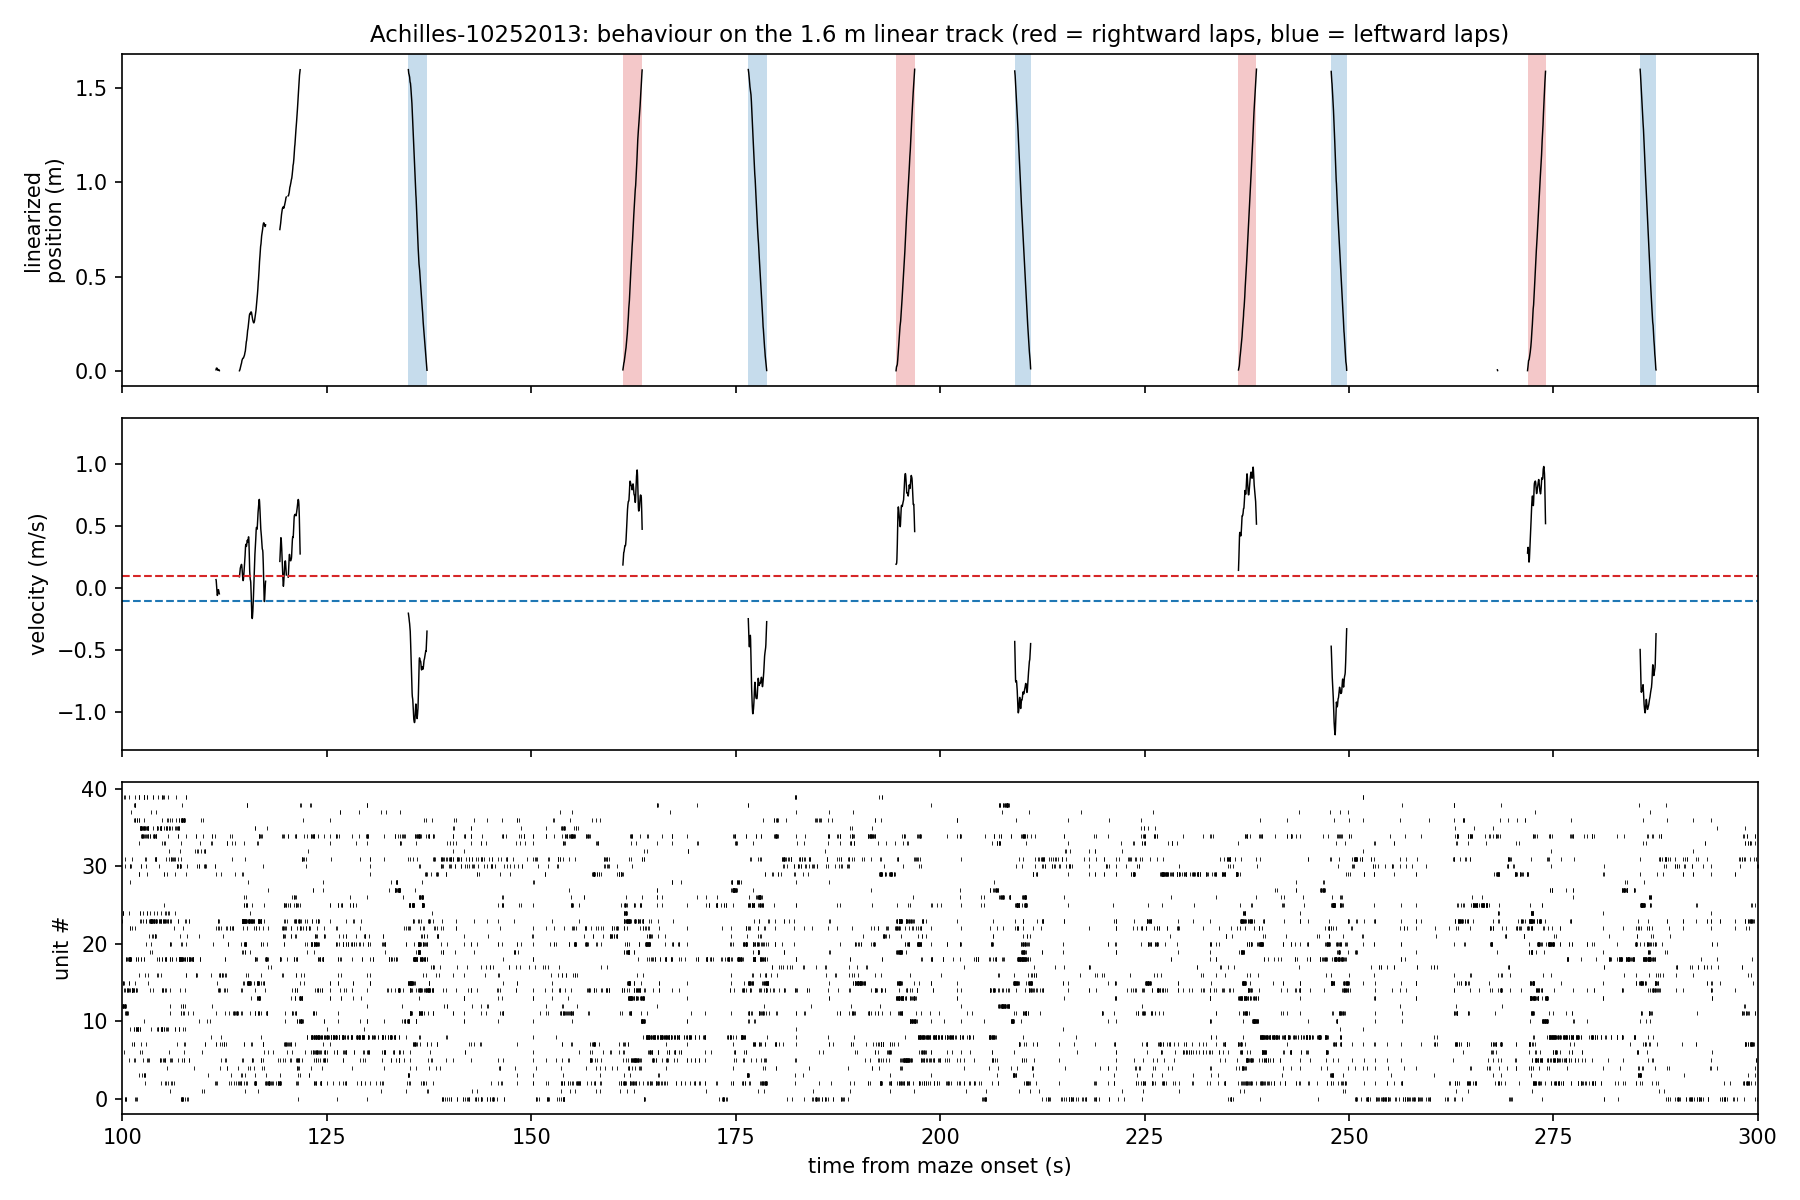

In [4]:
nwb = nap.NWBFile(nwbfile)
units = nwb["units"]
exc = units.getby_category("cell_type")["excitatory"]
print(f"{len(units)} units: {units.get_info('cell_type').value_counts().to_dict()}")
print(f"locations: {units.get_info('location').value_counts().to_dict()}")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
t0 = maze.start[0]
axes[0].plot(pos.times() - t0, pos.values, "k", lw=0.7)
for ep, c in ((runs_r, "tab:red"), (runs_l, "tab:blue")):
    for s, e in zip(ep.start, ep.end):
        axes[0].axvspan(s - t0, e - t0, color=c, alpha=0.25, lw=0)
axes[0].set_ylabel("linearized\nposition (m)")
axes[0].set_title(f"{EXAMPLE_SESSION}: behaviour on the {track_len:.1f} m linear track "
                  "(red = rightward laps, blue = leftward laps)")

axes[1].plot(vel.times() - t0, vel.values, "k", lw=0.7)
axes[1].axhline(SPEED_THRESH, color="tab:red", ls="--", lw=1)
axes[1].axhline(-SPEED_THRESH, color="tab:blue", ls="--", lw=1)
axes[1].set_ylabel("velocity (m/s)")

for i, uid in enumerate(list(exc.keys())[:40]):
    st = exc[uid].restrict(maze).times() - t0
    axes[2].plot(st, np.full(st.size, i), "|", color="k", ms=2, mew=0.4)
axes[2].set_ylabel("unit #")
axes[2].set_xlabel("time from maze onset (s)")
axes[2].set_xlim(100, 300)
fig.tight_layout()
fig.savefig("fig01_behavior_and_raster.png", dpi=150)
plt.close(fig)
display(Image("fig01_behavior_and_raster.png"))

## Theta: choosing a reference channel and extracting phase

Theta amplitude varies strongly with depth across the 128 recording sites, so rather than
picking a channel by hand the channel with the largest theta-to-delta power ratio during
running is selected automatically. The LFP is then band-pass filtered at 6-12 Hz with a
zero-phase Butterworth filter and the instantaneous phase is taken from the Hilbert
transform, with 0 degrees at the peak of the filtered signal.

Only the maze epoch of the chosen channel is read, which is a few megabytes rather than
the multi-gigabyte full array.

In [5]:
def bandpass(x, lo, hi, fs, order=3):
    b, a = butter(order, [lo / (fs / 2), hi / (fs / 2)], btype="band")
    return filtfilt(b, a, x)


def read_lfp_channel(f, chan, t_start, t_stop):
    dset = f["processing/ecephys/LFP/LFP/data"]
    conv = float(dset.attrs["conversion"])
    i0, i1 = int(np.floor(t_start * LFP_RATE)), int(np.ceil(t_stop * LFP_RATE))
    i1 = min(i1, dset.shape[0])
    return nap.Tsd(t=np.arange(i0, i1) / LFP_RATE,
                   d=np.asarray(dset[i0:i1, chan], dtype=np.float64) * conv)


def theta_power_ratio(x, fs):
    fr, p = welch(x, fs=fs, nperseg=int(4 * fs))
    th = p[(fr >= THETA_BAND[0]) & (fr <= THETA_BAND[1])].mean()
    de = p[(fr >= 1) & (fr <= 4)].mean()
    return th / de, (fr, p)


def pick_theta_channel(f, run_epochs, n_probe_s=120.0):
    dset = f["processing/ecephys/LFP/LFP/data"]
    t0 = float(run_epochs.start[0])
    i0, i1 = int(t0 * LFP_RATE), int((t0 + n_probe_s) * LFP_RATE)
    block = np.asarray(dset[i0:i1, :], dtype=np.float64) * float(dset.attrs["conversion"])
    ratios = np.array([theta_power_ratio(block[:, c], LFP_RATE)[0]
                       for c in range(dset.shape[1])])
    return int(np.argmax(ratios)), ratios


def theta_phase(lfp, fs=LFP_RATE):
    """Filtered theta, instantaneous phase (0 = peak) and amplitude envelope."""
    filt = bandpass(lfp.values, THETA_BAND[0], THETA_BAND[1], fs)
    analytic = hilbert(filt)
    t = lfp.times()
    return (nap.Tsd(t=t, d=filt), nap.Tsd(t=t, d=np.angle(analytic)),
            nap.Tsd(t=t, d=np.abs(analytic)))


chan, ratios = pick_theta_channel(f, runs_r)
lfp = read_lfp_channel(f, chan, maze.start[0], maze.end[0])
filt, phase, amp = theta_phase(lfp)
print(f"reference channel {chan}: theta/delta ratio {ratios[chan]:.2f} "
      f"(median over 128 channels {np.median(ratios):.2f})")

reference channel 117: theta/delta ratio 2.88 (median over 128 channels 1.35)


### Figure 2: validating the theta extraction

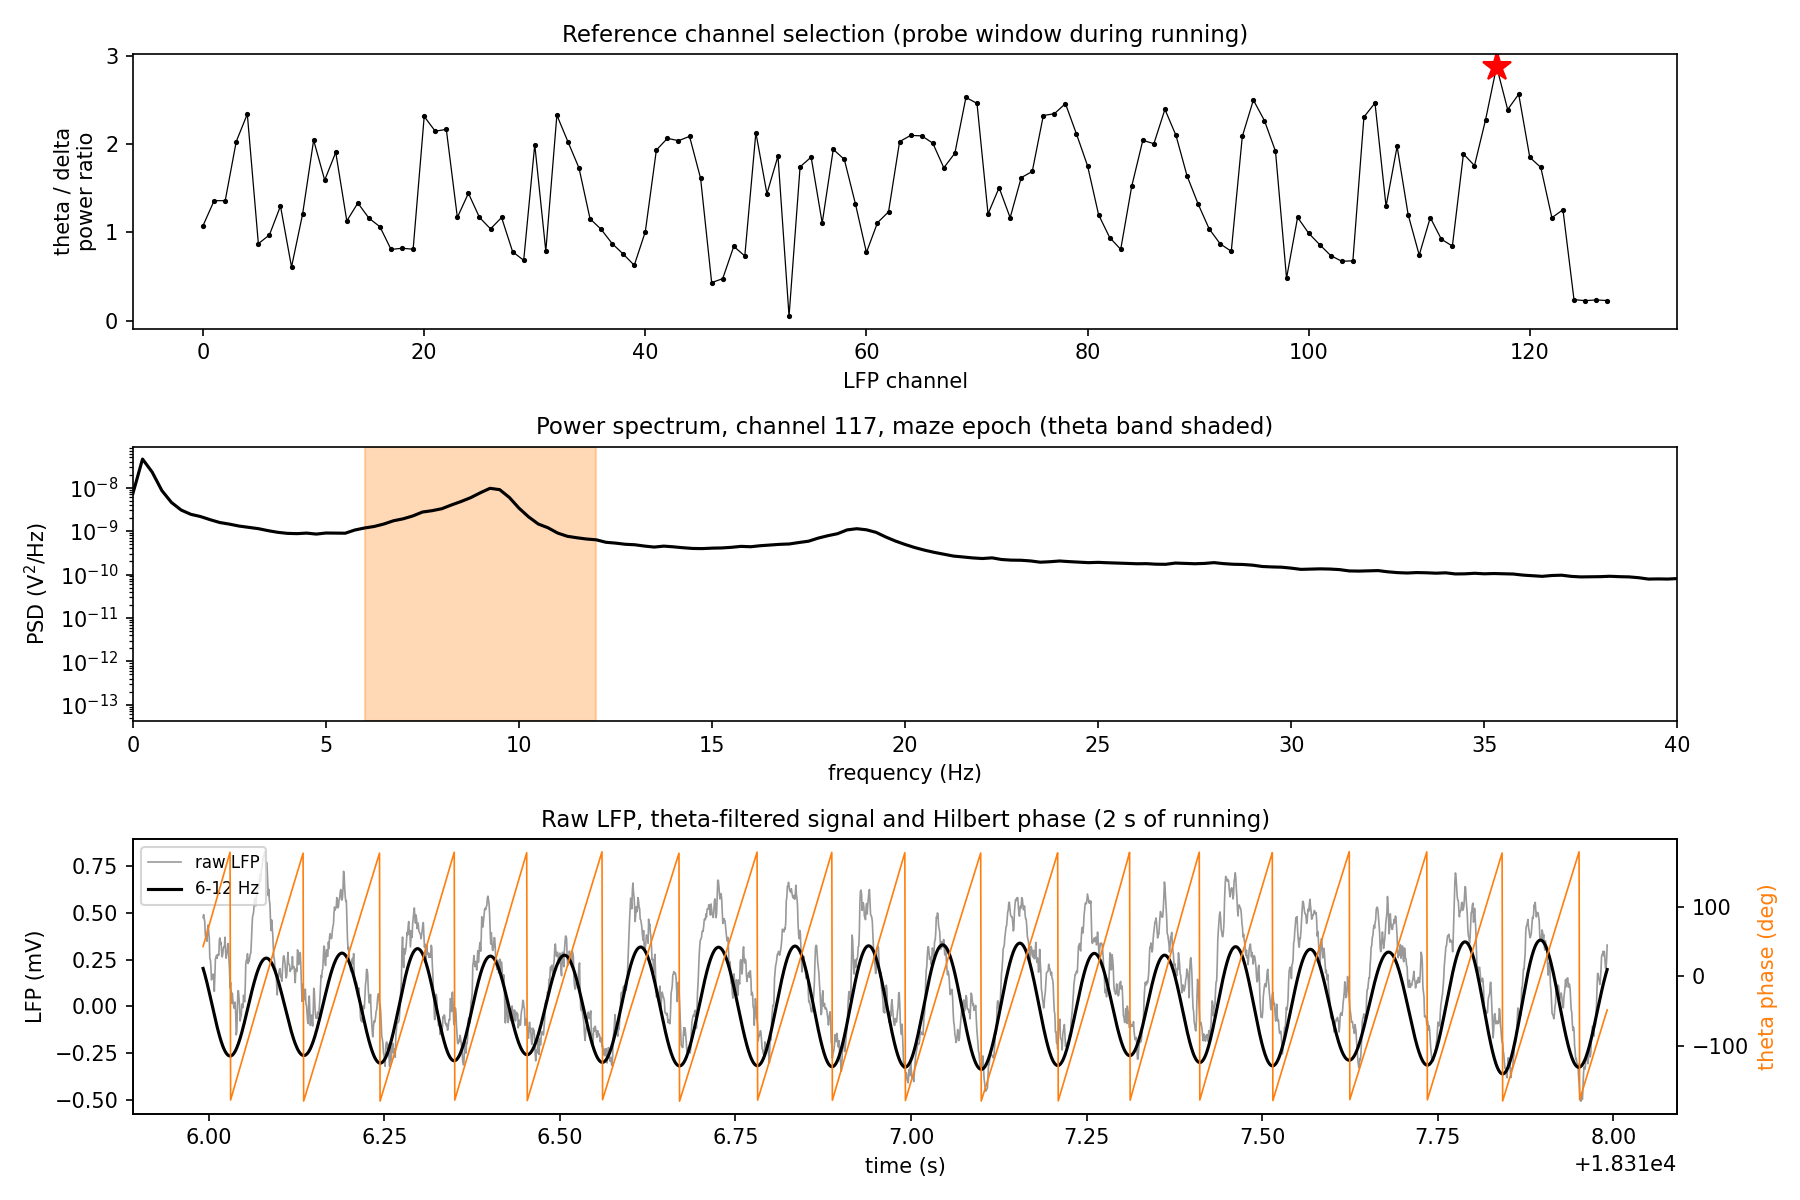

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(ratios, "k.-", ms=3, lw=0.6)
axes[0].plot(chan, ratios[chan], "r*", ms=14)
axes[0].set_xlabel("LFP channel")
axes[0].set_ylabel("theta / delta\npower ratio")
axes[0].set_title("Reference channel selection (probe window during running)")

_, (fr, psd) = theta_power_ratio(lfp.restrict(maze).values, LFP_RATE)
axes[1].semilogy(fr, psd, "k")
axes[1].axvspan(*THETA_BAND, color="tab:orange", alpha=0.3)
axes[1].set_xlim(0, 40)
axes[1].set_xlabel("frequency (Hz)")
axes[1].set_ylabel("PSD (V$^2$/Hz)")
axes[1].set_title(f"Power spectrum, channel {chan}, maze epoch (theta band shaded)")

w = nap.IntervalSet(start=runs_r.start[2], end=runs_r.start[2] + 2.0)
axes[2].plot(lfp.restrict(w).times(), lfp.restrict(w).values * 1e3, color="0.6", lw=0.8,
             label="raw LFP")
axes[2].plot(filt.restrict(w).times(), filt.restrict(w).values * 1e3, "k", lw=1.5,
             label="6-12 Hz")
ax2b = axes[2].twinx()
ax2b.plot(phase.restrict(w).times(), np.degrees(phase.restrict(w).values),
          color="tab:orange", lw=0.8)
ax2b.set_ylabel("theta phase (deg)", color="tab:orange")
axes[2].set_xlabel("time (s)")
axes[2].set_ylabel("LFP (mV)")
axes[2].legend(loc="upper left", fontsize=8)
axes[2].set_title("Raw LFP, theta-filtered signal and Hilbert phase (2 s of running)")
fig.tight_layout()
fig.savefig("fig02_lfp_theta_validation.png", dpi=150)
plt.close(fig)
display(Image("fig02_lfp_theta_validation.png"))

## Place fields

Tuning curves are computed separately for rightward and leftward laps, because CA1 fields
on a linear track are usually directional. A cell-direction pair is kept as a place field
if the smoothed peak rate is at least 1 Hz, Skaggs spatial information is at least
0.5 bits/spike, the field (the contiguous region above 20% of the peak) is between 10 cm
and 1 m wide, the field peak is not within 9% of the track length of either end, and at
least 50 spikes fall inside the field during running.

In [7]:
def spatial_info(tc, occupancy):
    """Skaggs spatial information, bits per spike."""
    p = occupancy / occupancy.sum()
    r = np.asarray(tc, dtype=float)
    rbar = np.nansum(p * r)
    if rbar <= 0:
        return 0.0
    ok = (r > 0) & (p > 0)
    return float(np.sum(p[ok] * (r[ok] / rbar) * np.log2(r[ok] / rbar)))


def field_bounds(tc_values, bins, frac=0.2):
    """Contiguous region around the peak where the rate exceeds frac * peak."""
    pk = int(np.nanargmax(tc_values))
    thr = frac * tc_values[pk]
    lo, hi = pk, pk
    while lo > 0 and tc_values[lo - 1] > thr:
        lo -= 1
    while hi < len(tc_values) - 1 and tc_values[hi + 1] > thr:
        hi += 1
    return bins[lo], bins[hi], bins[pk]


n_bins = int(round(track_len / BIN_SIZE))
bins = np.linspace(0, track_len, n_bins + 1)
centers = 0.5 * (bins[1:] + bins[:-1])
runs = {"right": runs_r, "left": runs_l}

tcs, occs = {}, {}
for d, ep in runs.items():
    tc = nap.compute_tuning_curves(exc, pos, bins=n_bins, range=[(0, track_len)],
                                   epochs=ep, fs=fs_pos, return_pandas=True)
    tcs[d] = tc.apply(lambda c: gaussian_filter1d(c.values, 1.0, mode="nearest"))
    occ, _ = np.histogram(pos.restrict(ep).values, bins=bins)
    occs[d] = occ / fs_pos

rows = []
for d in runs:
    for uid in tcs[d].columns:
        v = tcs[d][uid].values
        if not np.isfinite(v).any() or np.nanmax(v) < MIN_PEAK_RATE:
            continue
        lo, hi, pk = field_bounds(v, centers)
        rows.append(dict(unit=uid, direction=d, peak_rate=float(np.nanmax(v)),
                         spatial_info=spatial_info(v, occs[d]), field_lo=lo, field_hi=hi,
                         field_peak=pk, field_width=hi - lo))
pf = pd.DataFrame(rows)
pf["is_place_cell"] = ((pf.spatial_info >= MIN_SPATIAL_INFO) & (pf.field_width >= 0.10)
                       & (pf.field_width <= 1.0)
                       & (pf.field_peak >= EDGE_FRAC * track_len)
                       & (pf.field_peak <= (1 - EDGE_FRAC) * track_len))
print(f"{pf.is_place_cell.sum()} of {len(pf)} unit-direction pairs pass the spatial criteria")

67 of 164 unit-direction pairs pass the spatial criteria


### Figure 3: place field maps

Sorting the normalised tuning curves by the location of their peak gives the familiar
diagonal band: the population tiles the whole track in both directions of travel.

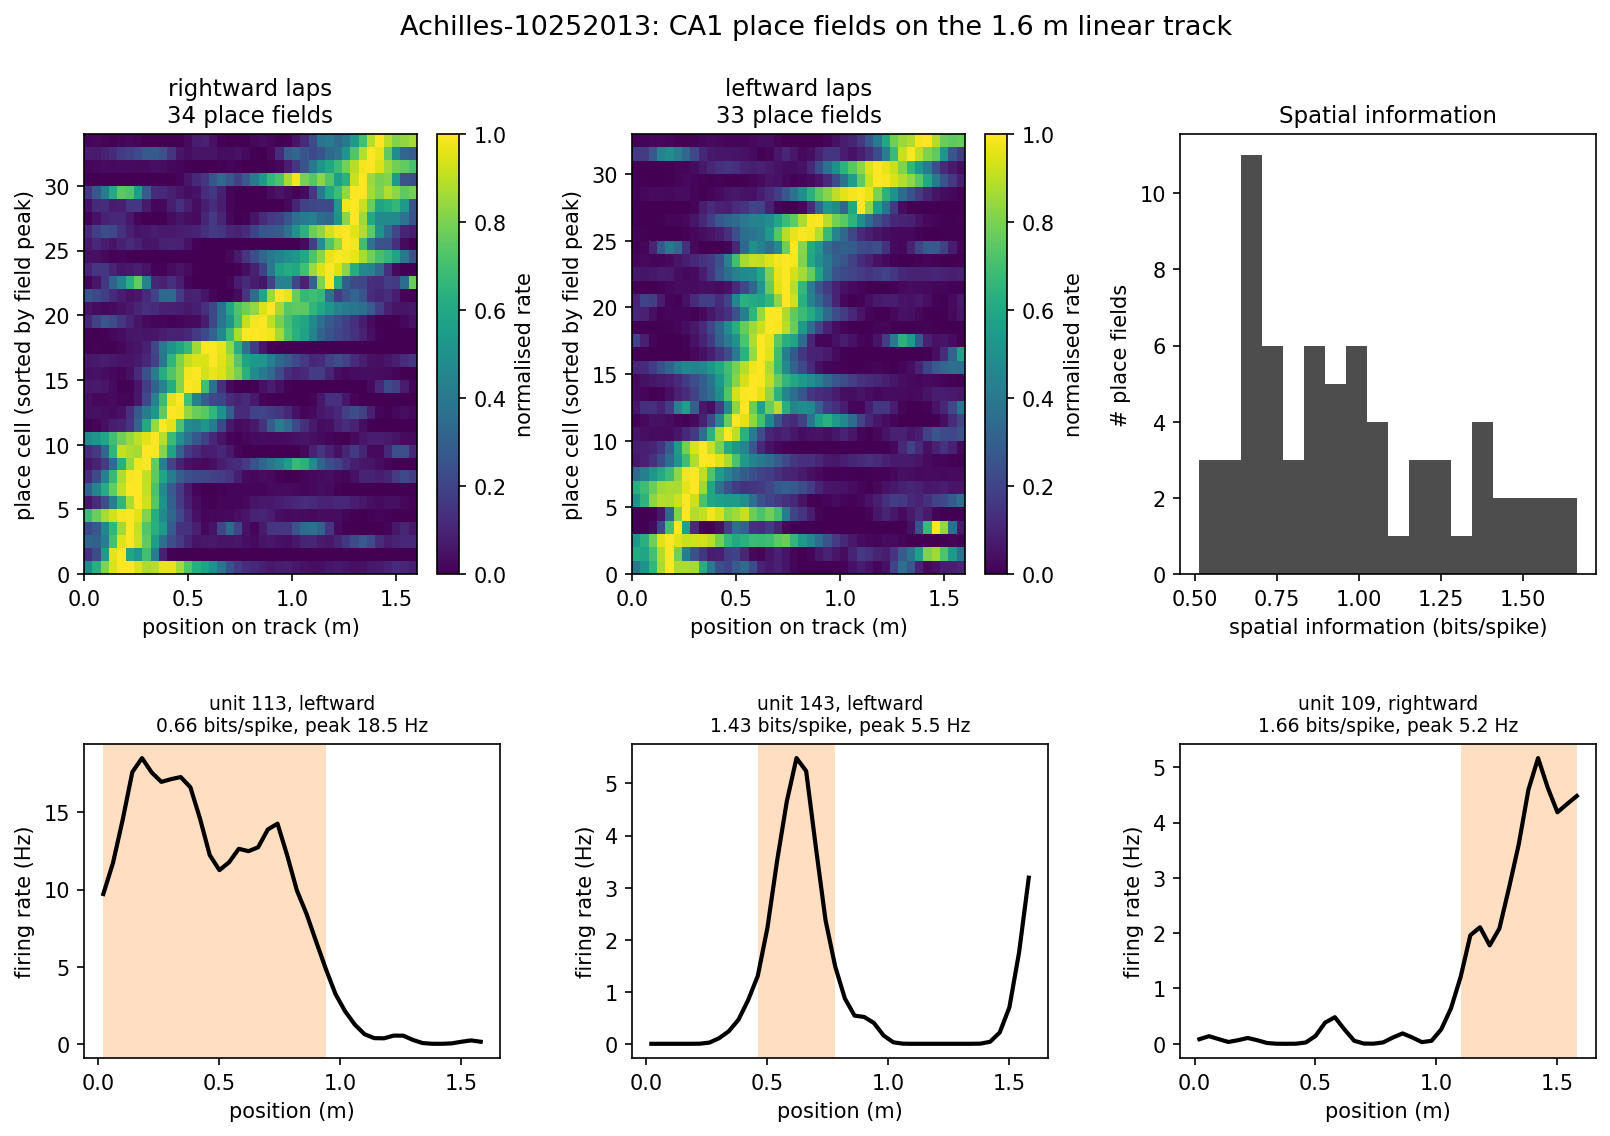

In [8]:
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1.4, 1], hspace=0.45, wspace=0.32)
for j, d in enumerate(("right", "left")):
    ax = fig.add_subplot(gs[0, j])
    sel = pf[(pf.direction == d) & pf.is_place_cell].sort_values("field_peak")
    mat = np.array([tcs[d][u].values for u in sel.unit])
    mat = mat / np.nanmax(mat, axis=1, keepdims=True)
    im = ax.imshow(mat, aspect="auto", origin="lower", cmap="viridis",
                   extent=[0, track_len, 0, len(sel)], interpolation="nearest")
    ax.set_xlabel("position on track (m)")
    ax.set_ylabel("place cell (sorted by field peak)")
    ax.set_title(f"{d}ward laps\n{len(sel)} place fields")
    fig.colorbar(im, ax=ax, label="normalised rate")

ax = fig.add_subplot(gs[0, 2])
ax.hist(pf[pf.is_place_cell].spatial_info, bins=18, color="0.3")
ax.set_xlabel("spatial information (bits/spike)")
ax.set_ylabel("# place fields")
ax.set_title("Spatial information")

# three example fields spread across the track
sel = pf[pf.is_place_cell].sort_values("field_peak")
for k, idx in enumerate(np.linspace(0, len(sel) - 1, 3).astype(int)):
    r = sel.iloc[idx]
    ax = fig.add_subplot(gs[1, k])
    ax.plot(centers, tcs[r.direction][r.unit].values, "k", lw=2)
    ax.axvspan(r.field_lo, r.field_hi, color="tab:orange", alpha=0.25, lw=0)
    ax.set_xlabel("position (m)")
    ax.set_ylabel("firing rate (Hz)")
    ax.set_title(f"unit {r.unit}, {r.direction}ward\n{r.spatial_info:.2f} bits/spike, "
                 f"peak {r.peak_rate:.1f} Hz", fontsize=9)
fig.suptitle(f"{EXAMPLE_SESSION}: CA1 place fields on the {track_len:.1f} m linear track",
             fontsize=13)
fig.savefig("fig03_place_fields.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("fig03_place_fields.png"))

## Quantifying precession

For every spike inside a field the two quantities of interest are its theta phase and how
far through the field the animal was when it fired. The position is normalised so that 0
is field entry and 1 is field exit *in the animal's direction of travel*, which lets
leftward and rightward fields be pooled.

Phase and position are related circularly, so ordinary linear regression does not apply.
Following Kempter et al. (2012), the slope `a` is the value that maximises the mean
resultant length of `exp(i * (phi - 2*pi*a*x))`, the offset is the circular mean of the
residuals, and the correlation coefficient is a circular-linear analogue of Pearson's r.
The search over `a` is symmetric about zero, so a negative answer is not built into the
method, but is limited to +/- 1.5 cycles per field because beyond that the resultant
length develops aliased side maxima.

Significance comes from a permutation test that shuffles which phase goes with which
position while leaving both marginal distributions intact. This is the right null here: it
preserves the cell's overall phase locking to theta and its uneven sampling of the field,
and destroys only the association between the two.

In [9]:
def circlin_regress(x, phi, slope_range=(-1.5, 1.5), n_grid=1201):
    """Fit phi = 2*pi*a*x + phi0. Returns (a in cycles per unit x, phi0, R, grid)."""
    x, phi = np.asarray(x, float), np.asarray(phi, float)
    a_grid = np.linspace(*slope_range, n_grid)
    R = np.abs(np.exp(1j * (phi[None, :] - 2 * np.pi * a_grid[:, None] * x[None, :])).mean(axis=1))
    a = a_grid[int(np.argmax(R))]
    phi0 = np.angle(np.exp(1j * (phi - 2 * np.pi * a * x)).mean())
    return a, phi0, R.max(), (a_grid, R)


def circlin_corr(x, phi, a):
    """Circular-linear correlation coefficient (Kempter et al. 2012)."""
    x, phi = np.asarray(x, float), np.asarray(phi, float)
    theta = (2 * np.pi * np.abs(a) * x) % (2 * np.pi)
    tb, pb = np.angle(np.exp(1j * theta).mean()), np.angle(np.exp(1j * phi).mean())
    num = np.sum(np.sin(phi - pb) * np.sin(theta - tb))
    den = np.sqrt(np.sum(np.sin(phi - pb) ** 2) * np.sum(np.sin(theta - tb) ** 2))
    # theta increases with x by construction, so the sign of rho already tracks the
    # sign of the fitted slope: negative rho means phase precession.
    return 0.0 if den == 0 else float(num / den)


def circlin_pvalue(x, phi, rho_obs, n_shuffle=N_SHUFFLE, rng=None,
                   slope_range=(-1.5, 1.5), n_grid=301):
    """Permutation p-value: break the phase-position pairing and refit."""
    rng = rng or np.random.default_rng(0)
    x, phi = np.asarray(x, float), np.asarray(phi, float)
    a_grid = np.linspace(*slope_range, n_grid)
    base = np.exp(-2j * np.pi * a_grid[:, None] * x[None, :])
    null = np.empty(n_shuffle)
    for i in range(n_shuffle):
        p = phi[rng.permutation(phi.size)]
        a = a_grid[int(np.argmax(np.abs((base * np.exp(1j * p)[None, :]).mean(axis=1))))]
        null[i] = circlin_corr(x, p, a)
    return float((np.sum(np.abs(null) >= abs(rho_obs)) + 1) / (n_shuffle + 1)), null


def field_spike_phase_position(spikes, ep, pos, phase, field_lo, field_hi, direction):
    """Normalised in-field position, theta phase and time for every in-field spike."""
    spk = spikes.restrict(ep)
    if len(spk) == 0:
        return np.array([]), np.array([]), np.array([])
    pr = pos.restrict(ep)
    sp_pos = np.interp(spk.times(), pr.times(), pr.values)
    keep = (sp_pos >= field_lo) & (sp_pos <= field_hi)
    sp_pos, t = sp_pos[keep], spk.times()[keep]
    x = ((sp_pos - field_lo) if direction == "right" else (field_hi - sp_pos)) \
        / (field_hi - field_lo)
    phi = np.interp(t, phase.times(), np.unwrap(phase.values))
    return x, (phi + np.pi) % (2 * np.pi) - np.pi, t

### The whole pipeline for one session

Everything above is collected into a single function so it can be applied to each session
in turn.

In [10]:
def analyse_session(session, n_shuffle=N_SHUFFLE, verbose=True):
    """Load a session, find place fields, fit precession in each. Returns (DataFrame, ctx)."""
    f, nwbfile = open_session(session)
    exc = nap.NWBFile(nwbfile)["units"].getby_category("cell_type")["excitatory"]

    pos, fs_pos, track_len, maze_name = load_position(f)
    vel, _ = compute_speed(pos, fs_pos)
    runs = dict(zip(("right", "left"), find_runs(pos, vel, fs_pos, track_len)))
    maze = maze_epoch(f)
    n_bins = int(round(track_len / BIN_SIZE))

    chan, _ = pick_theta_channel(f, runs["right"])
    lfp = read_lfp_channel(f, chan, maze.start[0], maze.end[0])
    filt, phase, _ = theta_phase(lfp)
    if verbose:
        print(f"[{session}] {len(exc)} excitatory units, "
              f"{len(runs['right'])}+{len(runs['left'])} laps on {maze_name} "
              f"({track_len:.1f} m), theta channel {chan}")

    bins = np.linspace(0, track_len, n_bins + 1)
    centers = 0.5 * (bins[1:] + bins[:-1])
    tcs, occs = {}, {}
    for d, ep in runs.items():
        tc = nap.compute_tuning_curves(exc, pos, bins=n_bins, range=[(0, track_len)],
                                       epochs=ep, fs=fs_pos, return_pandas=True)
        tcs[d] = tc.apply(lambda c: gaussian_filter1d(c.values, 1.0, mode="nearest"))
        occ, _ = np.histogram(pos.restrict(ep).values, bins=bins)
        occs[d] = occ / fs_pos

    rng = np.random.default_rng(1)
    rows, per_field = [], {}
    todo = [(u, d) for d in runs for u in tcs[d].columns]
    for uid, d in tqdm(todo, desc=f"{session}: fields", disable=not verbose, leave=False):
        v = tcs[d][uid].values
        if not np.isfinite(v).any() or np.nanmax(v) < MIN_PEAK_RATE:
            continue
        si = spatial_info(v, occs[d])
        lo, hi, pk = field_bounds(v, centers)
        x, phi, t = field_spike_phase_position(exc[uid], runs[d], pos, phase, lo, hi, d)
        row = dict(session=session, maze=maze_name, track_len=track_len, unit=uid,
                   direction=d, peak_rate=float(np.nanmax(v)), spatial_info=si,
                   field_lo=lo, field_hi=hi, field_peak=pk, field_width=hi - lo,
                   n_field_spikes=len(x))
        row["is_place_cell"] = bool(
            si >= MIN_SPATIAL_INFO and 0.10 <= hi - lo <= 1.0
            and EDGE_FRAC * track_len <= pk <= (1 - EDGE_FRAC) * track_len
            and len(x) >= MIN_FIELD_SPIKES)
        if row["is_place_cell"]:
            a, phi0, _, _ = circlin_regress(x, phi)
            rho = circlin_corr(x, phi, a)
            p, null = circlin_pvalue(x, phi, rho, n_shuffle=n_shuffle, rng=rng)
            row.update(slope_cycles=a, slope_deg=a * 360.0, phi0=phi0, rho=rho, pval=p)
            per_field[(uid, d)] = dict(x=x, phi=phi, tc=v, lo=lo, hi=hi, null=null, **row)
        rows.append(row)

    ctx = dict(pos=pos, vel=vel, runs=runs, track_len=track_len, lfp=lfp, filt=filt,
               phase=phase, exc=exc, tcs=tcs, centers=centers, per_field=per_field,
               chan=chan, maze=maze)
    return pd.DataFrame(rows), ctx


df, ctx = analyse_session(EXAMPLE_SESSION)
pc = df[df.is_place_cell].copy()
per_field = ctx["per_field"]
sig = pc.pval < 0.05
print(f"\n{len(pc)} place fields; {sig.sum()} with significant circular-linear "
      f"correlation ({100 * sig.mean():.0f}%), of which "
      f"{(sig & (pc.rho < 0)).sum()} are negative (precessing)")
print(f"median slope {pc.slope_deg.median():.0f} deg/field, "
      f"{(pc.slope_cycles < 0).mean() * 100:.0f}% negative; median rho {pc.rho.median():.3f}")

[Achilles-10252013] 120 excitatory units, 39+42 laps on 1.6mLinearMazeLinearizedPosition (1.6 m), theta channel 117


Achilles-10252013: fields:   0%|          | 0/240 [00:00<?, ?it/s]


45 place fields; 36 with significant circular-linear correlation (80%), of which 32 are negative (precessing)
median slope -240 deg/field, 87% negative; median rho -0.281


### Figure 4: the effect in the raw signals

The left column follows a single pass through one cell's field. As the animal moves
through the field the spikes appear at progressively earlier points on each successive
theta cycle, and the phase falls monotonically. The right panel accumulates every pass
through that field: the same relationship survives averaging over dozens of laps.

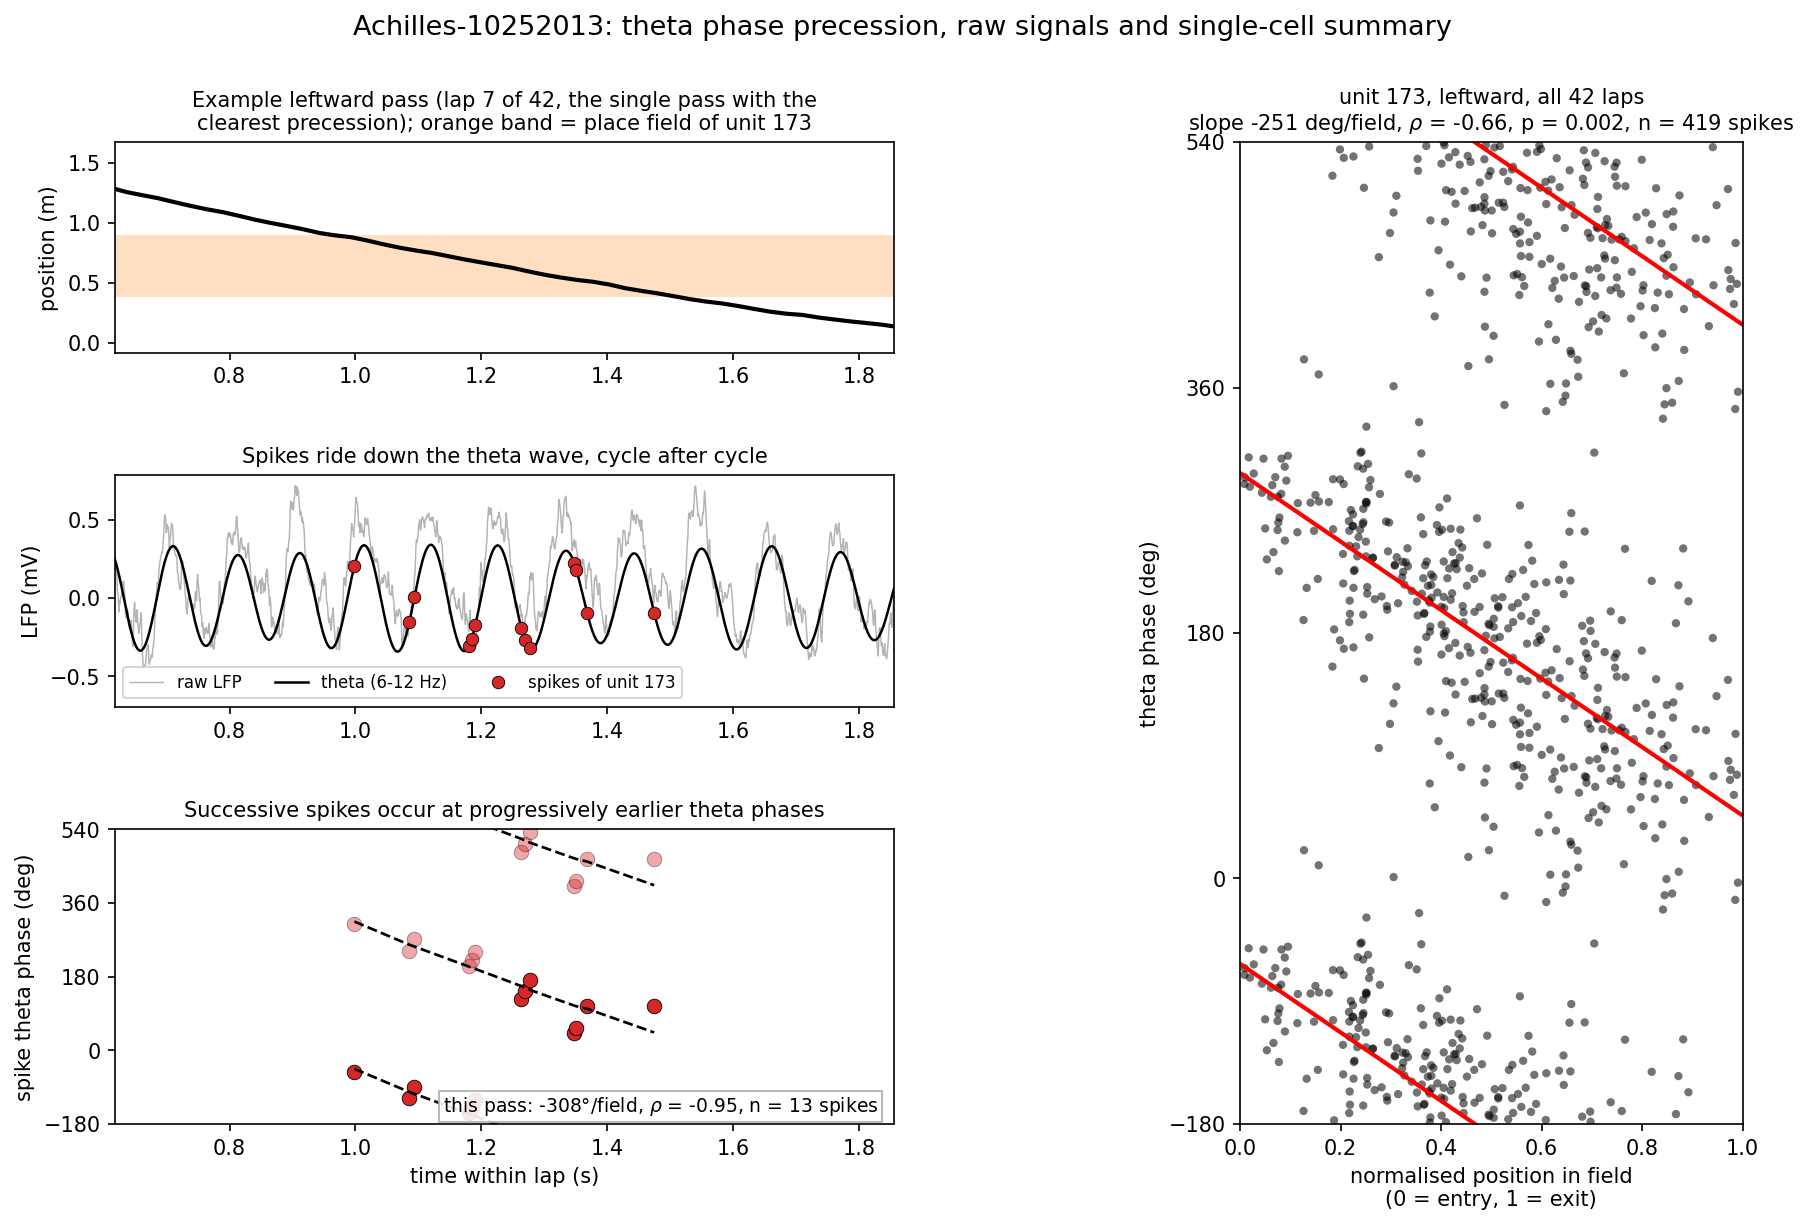

In [11]:
best = pc.sort_values("rho").iloc[0]
fd = per_field[(best.unit, best.direction)]
ep = ctx["runs"][best.direction]
spk = ctx["exc"][best.unit]

lap_scores = []
for s_, e_ in zip(ep.start, ep.end):
    one = nap.IntervalSet(start=s_, end=e_)
    xl, pl_, _ = field_spike_phase_position(spk, one, ctx["pos"], ctx["phase"],
                                            fd["lo"], fd["hi"], best.direction)
    if len(xl) < 8:
        lap_scores.append(np.inf)
        continue
    al, _, _, _ = circlin_regress(xl, pl_)
    lap_scores.append(circlin_corr(xl, pl_, al))
lap_i = int(np.argmin(lap_scores))
lap = nap.IntervalSet(start=ep.start[lap_i] - 0.2, end=ep.end[lap_i] + 0.2)

fig = plt.figure(figsize=(14, 8.5))
gs = GridSpec(3, 3, figure=fig, height_ratios=[1, 1.1, 1.4], hspace=0.5, wspace=0.32,
              width_ratios=[1.55, 0.12, 1])
t0 = lap.start[0]

axp = fig.add_subplot(gs[0, 0])
p_lap = ctx["pos"].restrict(lap)
axp.plot(p_lap.times() - t0, p_lap.values, "k", lw=2)
axp.axhspan(fd["lo"], fd["hi"], color="tab:orange", alpha=0.25, lw=0)
axp.set_ylabel("position (m)")
axp.set_title(f"Example {best.direction}ward pass (lap {lap_i + 1} of {len(ep)}, the single "
              f"pass with the\nclearest precession); orange band = place field of unit "
              f"{best.unit}", fontsize=10)

axl = fig.add_subplot(gs[1, 0], sharex=axp)
l_lap, f_lap = ctx["lfp"].restrict(lap), ctx["filt"].restrict(lap)
axl.plot(l_lap.times() - t0, l_lap.values * 1e3, color="0.7", lw=0.7, label="raw LFP")
axl.plot(f_lap.times() - t0, f_lap.values * 1e3, "k", lw=1.2, label="theta (6-12 Hz)")
st = spk.restrict(lap)
sp_phi = np.degrees((np.interp(st.times(), ctx["phase"].times(),
                               np.unwrap(ctx["phase"].values)) + np.pi) % (2 * np.pi) - np.pi)
axl.plot(st.times() - t0, np.interp(st.times(), f_lap.times(), f_lap.values) * 1e3,
         "o", mfc="tab:red", mec="k", mew=0.4, ms=6, zorder=5,
         label=f"spikes of unit {best.unit}")
axl.set_ylabel("LFP (mV)")
axl.legend(loc="lower left", fontsize=8, ncol=3)
axl.set_title("Spikes ride down the theta wave, cycle after cycle", fontsize=10)

axs = fig.add_subplot(gs[2, 0], sharex=axp)
axs.plot(st.times() - t0, sp_phi, "o", mfc="tab:red", mec="k", mew=0.4, ms=7)
axs.plot(st.times() - t0, sp_phi + 360, "o", mfc="tab:red", mec="k", mew=0.4, ms=7, alpha=0.4)
one = nap.IntervalSet(start=ep.start[lap_i], end=ep.end[lap_i])
xl, pl_, tl = field_spike_phase_position(spk, one, ctx["pos"], ctx["phase"],
                                         fd["lo"], fd["hi"], best.direction)
a1, p01, _, _ = circlin_regress(xl, pl_)
rho1 = circlin_corr(xl, pl_, a1)
order = np.argsort(xl)
for off in (-720, -360, 0, 360, 720):
    axs.plot(tl[order] - t0, np.degrees(2 * np.pi * a1 * xl[order] + p01) + off, "k--", lw=1.3)
axs.text(0.98, 0.04, f"this pass: {a1 * 360:.0f}$\\degree$/field, $\\rho$ = {rho1:.2f}, "
         f"n = {len(xl)} spikes", transform=axs.transAxes, fontsize=9, ha="right",
         bbox=dict(fc="w", ec="0.7", alpha=0.9, pad=2))
axs.set_ylim(-180, 540)
axs.set_yticks([-180, 0, 180, 360, 540])
axs.set_ylabel("spike theta phase (deg)")
axs.set_xlabel("time within lap (s)")
axs.set_title("Successive spikes occur at progressively earlier theta phases", fontsize=10)
in_field = (p_lap.values >= fd["lo"]) & (p_lap.values <= fd["hi"])
tf = p_lap.times()[in_field]
axp.set_xlim(tf[0] - t0 - 0.35, tf[-1] - t0 + 0.35)

axr = fig.add_subplot(gs[:, 2])
x, phi = fd["x"], np.degrees(fd["phi"])
for off in (0, 360):
    axr.scatter(x, phi + off, s=16, c="k", alpha=0.55, edgecolors="none")
xx = np.linspace(0, 1, 100)
for off in (-360, 0, 360, 720):
    axr.plot(xx, np.degrees(2 * np.pi * best.slope_cycles * xx + best.phi0) + off, "r", lw=2)
axr.set_ylim(-180, 540)
axr.set_yticks([-180, 0, 180, 360, 540])
axr.set_xlim(0, 1)
axr.set_xlabel("normalised position in field\n(0 = entry, 1 = exit)")
axr.set_ylabel("theta phase (deg)")
axr.set_title(f"unit {best.unit}, {best.direction}ward, all {len(ep)} laps\n"
              f"slope {best.slope_deg:.0f} deg/field, $\\rho$ = {best.rho:.2f}, "
              f"p = {best.pval:.3f}, n = {len(x)} spikes", fontsize=10)
fig.suptitle(f"{EXAMPLE_SESSION}: theta phase precession, raw signals and single-cell summary",
             fontsize=13)
fig.savefig("fig04_precession_example.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("fig04_precession_example.png"))

### Figure 5: a gallery of individual fields

The eight fields with the most in-field spikes among those that reached significance with
a negative correlation. The phase axis is drawn over two cycles so that the descending band
is not broken by the wrap at +/- 180 degrees.

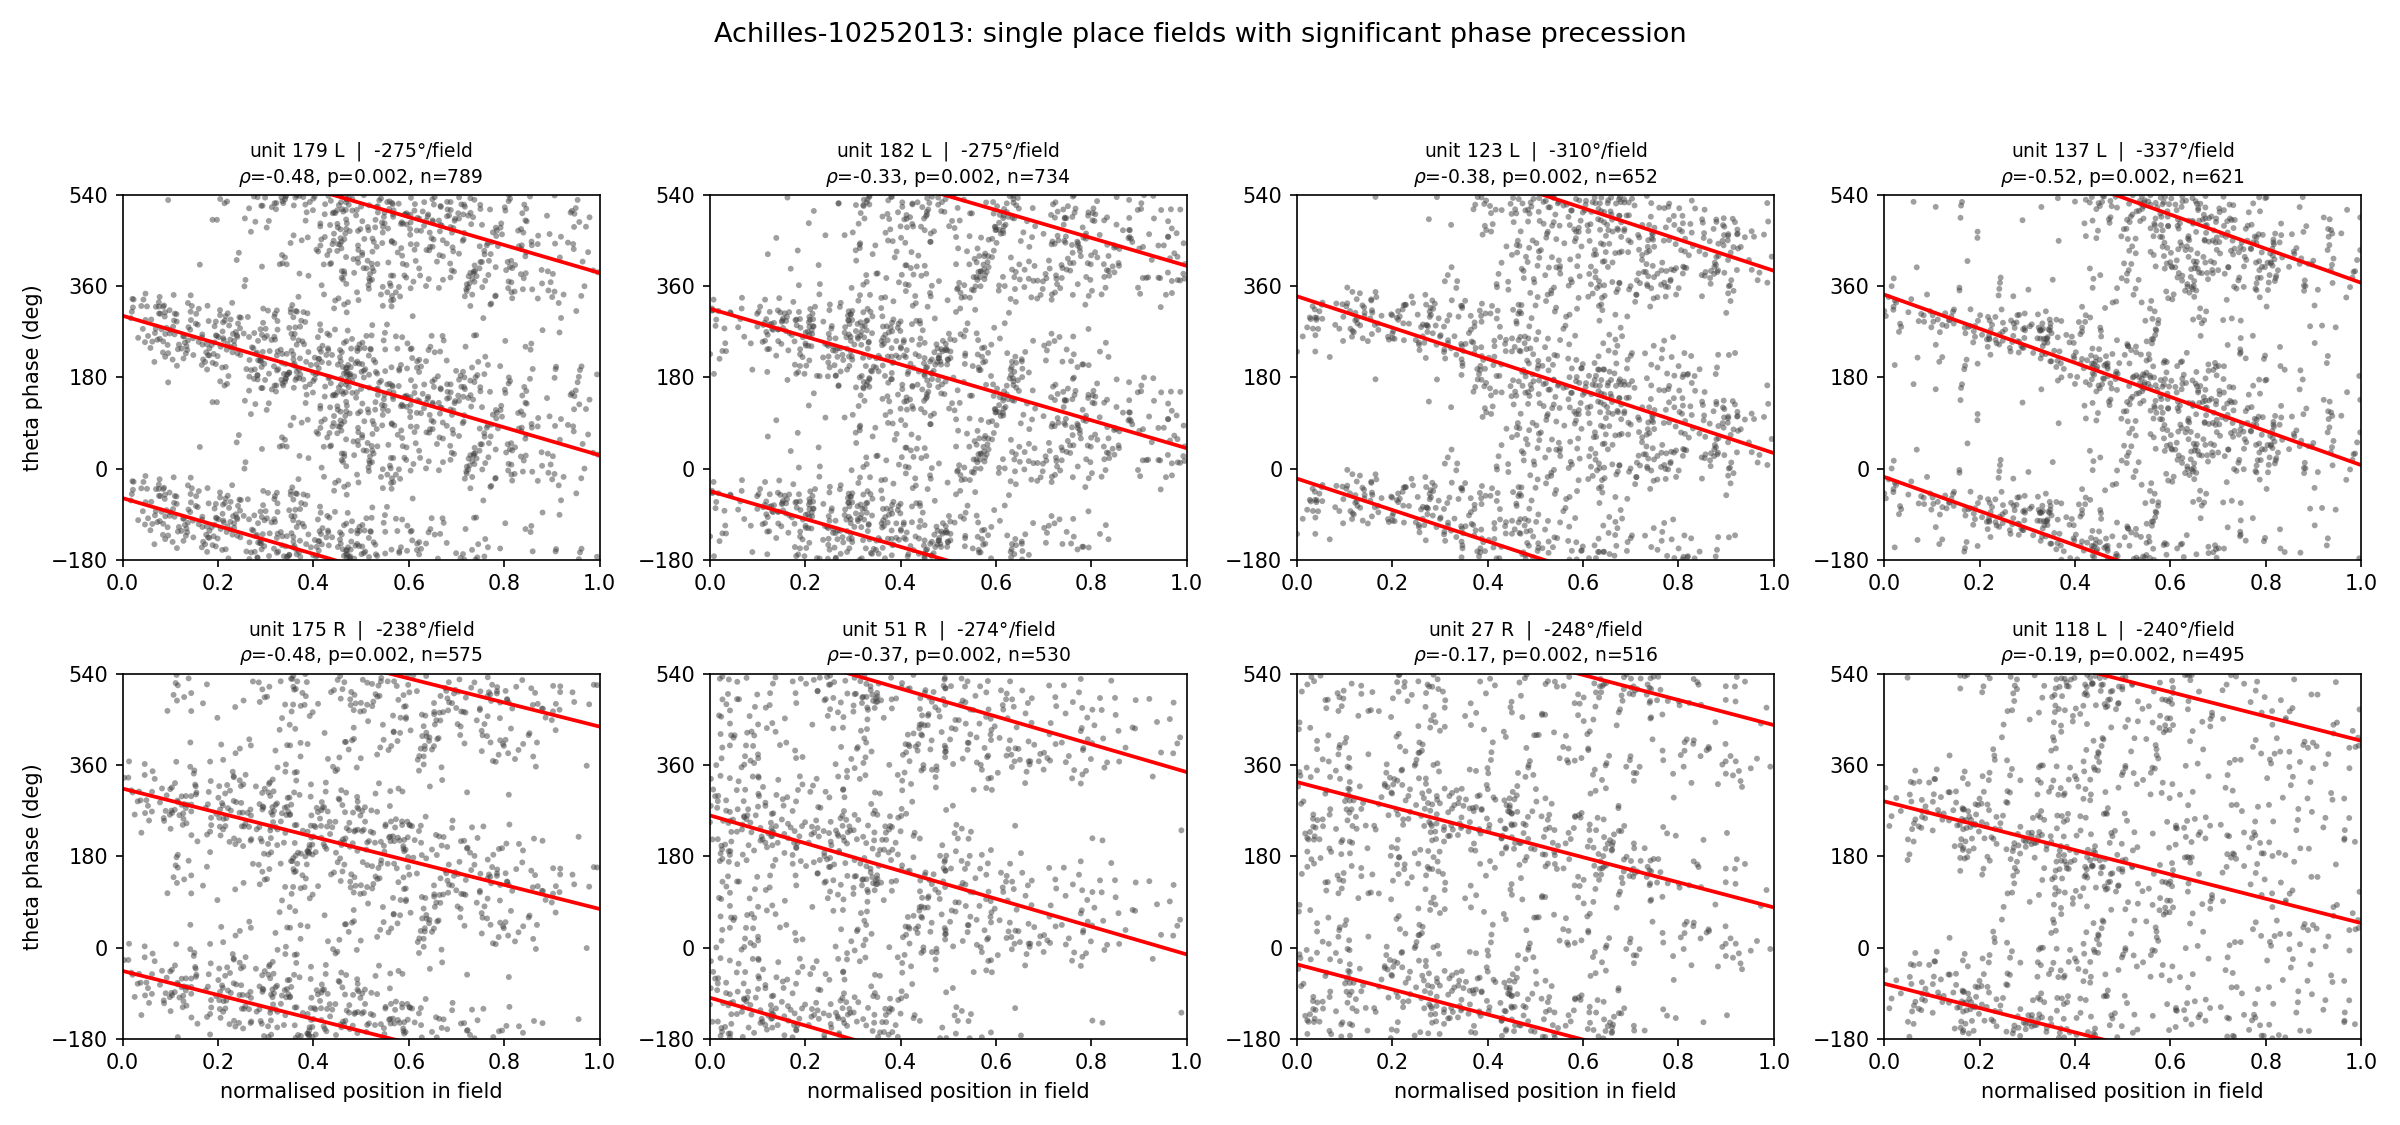

In [12]:
gallery = pc[sig & (pc.rho < 0)].sort_values("n_field_spikes", ascending=False).head(8)
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
for ax, (_, r) in zip(axes.ravel(), gallery.iterrows()):
    g = per_field[(r.unit, r.direction)]
    for off in (0, 360):
        ax.scatter(g["x"], np.degrees(g["phi"]) + off, s=8, c="0.25", alpha=0.5,
                   edgecolors="none")
    xx = np.linspace(0, 1, 100)
    for off in (-360, 0, 360, 720):
        ax.plot(xx, np.degrees(2 * np.pi * r.slope_cycles * xx + r.phi0) + off, "r", lw=1.8)
    ax.set_ylim(-180, 540)
    ax.set_xlim(0, 1)
    ax.set_yticks([-180, 0, 180, 360, 540])
    ax.set_title(f"unit {r.unit} {r.direction[0].upper()}  |  {r.slope_deg:.0f}$\\degree$/field\n"
                 f"$\\rho$={r.rho:.2f}, p={r.pval:.3f}, n={int(r.n_field_spikes)}", fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("theta phase (deg)")
for ax in axes[-1, :]:
    ax.set_xlabel("normalised position in field")
fig.suptitle(f"{EXAMPLE_SESSION}: single place fields with significant phase precession",
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("fig05_precession_gallery.png", dpi=150)
plt.close(fig)
display(Image("fig05_precession_gallery.png"))

### Figure 6: population statistics for this session

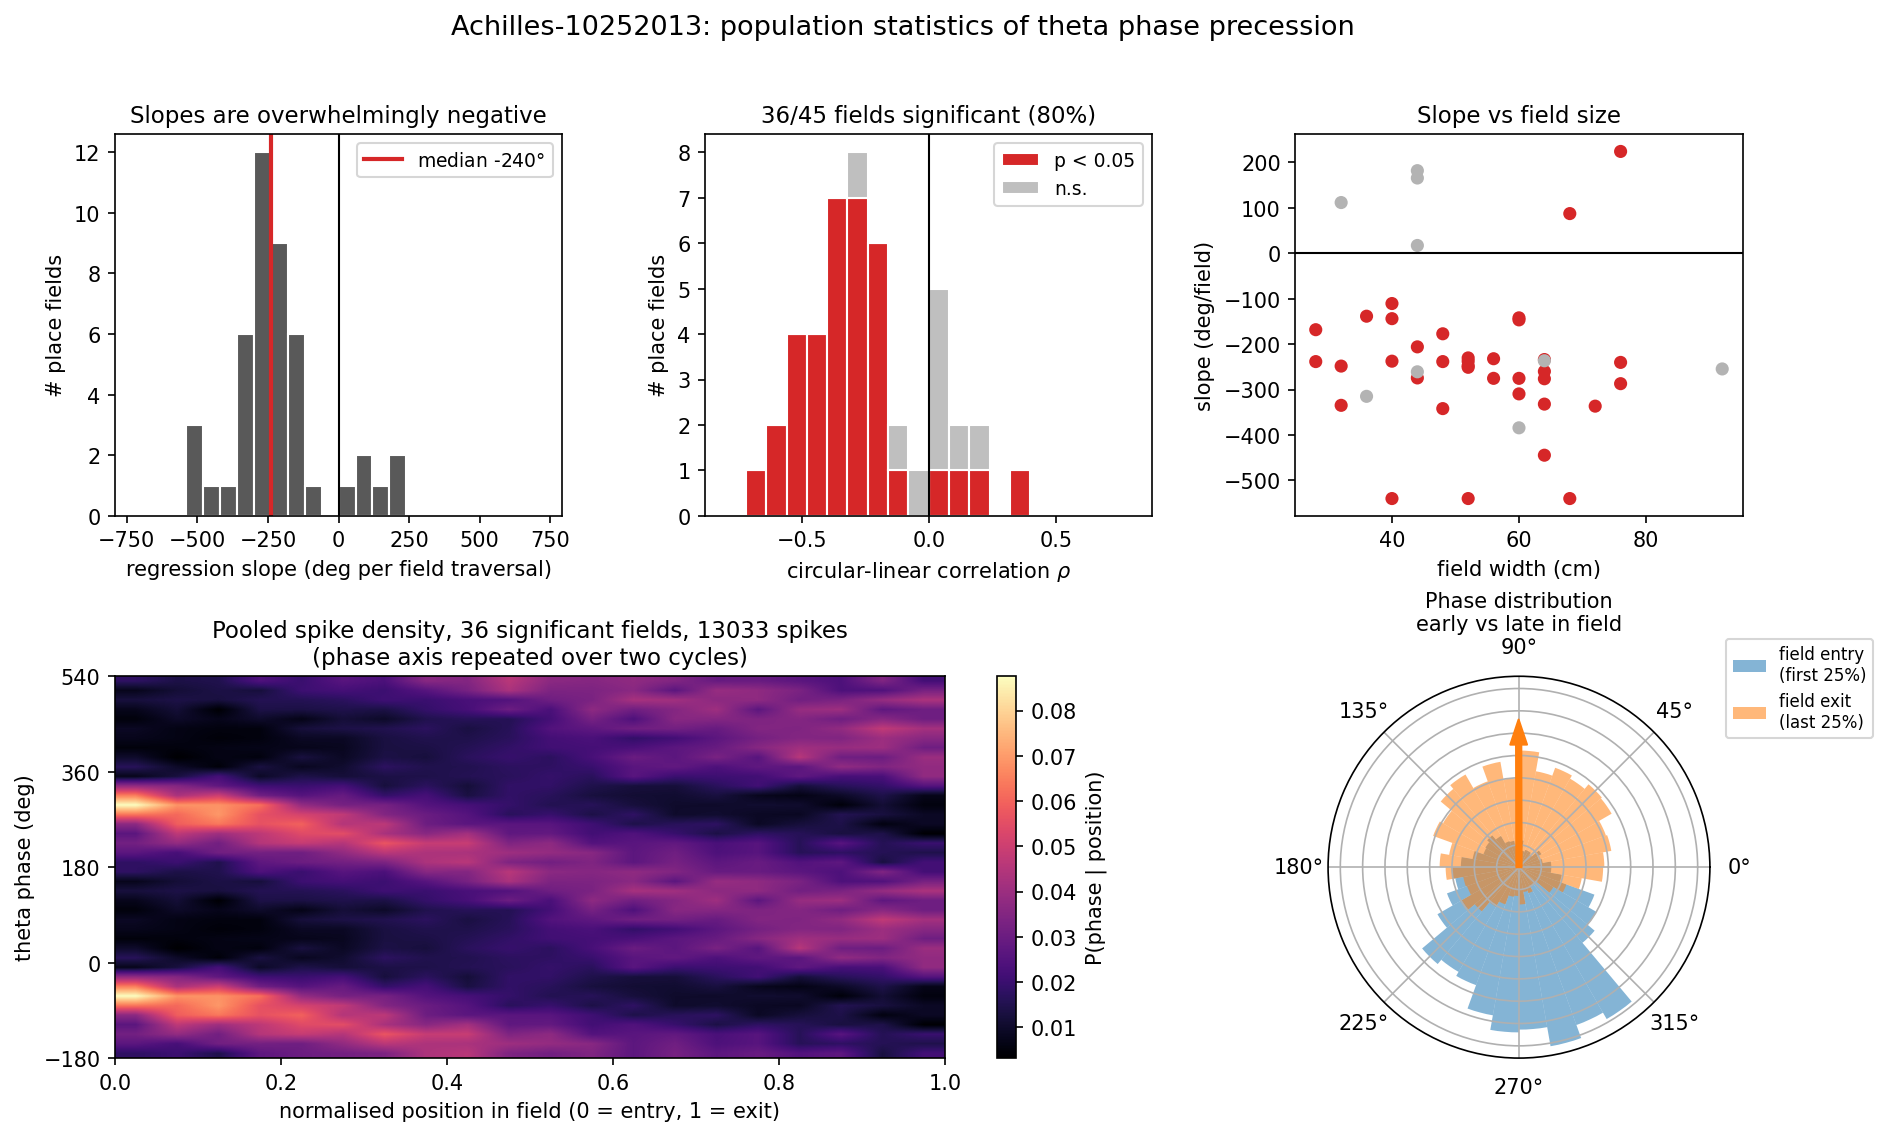

In [13]:
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

ax = fig.add_subplot(gs[0, 0])
ax.hist(pc.slope_deg, bins=np.arange(-720, 760, 60), color="0.35", edgecolor="w")
ax.axvline(0, color="k", lw=1)
ax.axvline(pc.slope_deg.median(), color="tab:red", lw=2,
           label=f"median {pc.slope_deg.median():.0f}$\\degree$")
ax.set_xlabel("regression slope (deg per field traversal)")
ax.set_ylabel("# place fields")
ax.set_title("Slopes are overwhelmingly negative")
ax.legend(fontsize=9)

ax = fig.add_subplot(gs[0, 1])
ax.hist([pc.rho[sig], pc.rho[~sig]], bins=np.arange(-0.8, 0.85, 0.08), stacked=True,
        color=["tab:red", "0.75"], edgecolor="w", label=["p < 0.05", "n.s."])
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("circular-linear correlation $\\rho$")
ax.set_ylabel("# place fields")
ax.set_title(f"{sig.sum()}/{len(pc)} fields significant ({100 * sig.mean():.0f}%)")
ax.legend(fontsize=9)

ax = fig.add_subplot(gs[0, 2])
ax.scatter(pc.field_width * 100, pc.slope_deg, c=np.where(sig, "tab:red", "0.7"), s=28)
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("field width (cm)")
ax.set_ylabel("slope (deg/field)")
ax.set_title("Slope vs field size")

ax = fig.add_subplot(gs[1, :2])
X = np.concatenate([per_field[(r.unit, r.direction)]["x"] for _, r in pc[sig].iterrows()])
P = np.degrees(np.concatenate([per_field[(r.unit, r.direction)]["phi"]
                               for _, r in pc[sig].iterrows()]))
H, xe, ye = np.histogram2d(np.r_[X, X], np.r_[P, P + 360],
                           bins=[np.linspace(0, 1, 21), np.linspace(-180, 540, 41)])
H = H / H.sum(axis=1, keepdims=True)
im = ax.imshow(H.T, origin="lower", aspect="auto", cmap="magma", extent=[0, 1, -180, 540],
               interpolation="bilinear")
ax.set_xlabel("normalised position in field (0 = entry, 1 = exit)")
ax.set_ylabel("theta phase (deg)")
ax.set_yticks([-180, 0, 180, 360, 540])
ax.set_title(f"Pooled spike density, {sig.sum()} significant fields, {len(X)} spikes\n"
             "(phase axis repeated over two cycles)")
fig.colorbar(im, ax=ax, label="P(phase | position)")

ax = fig.add_subplot(gs[1, 2], projection="polar")
for lo, hi, c, lab in ((0.0, 0.25, "tab:blue", "field entry\n(first 25%)"),
                       (0.75, 1.0, "tab:orange", "field exit\n(last 25%)")):
    m = (X >= lo) & (X < hi)
    ph = np.radians(P[m])
    ax.hist(ph % (2 * np.pi), bins=36, range=(0, 2 * np.pi), alpha=0.55, color=c,
            label=lab, density=True)
    R = np.exp(1j * ph).mean()
    ax.annotate("", xy=(np.angle(R), np.abs(R) * 1.2), xytext=(0, 0),
                arrowprops=dict(color=c, width=2.5, headwidth=8))
ax.set_theta_zero_location("E")
ax.set_yticklabels([])
ax.set_title("Phase distribution\nearly vs late in field", fontsize=10, pad=22)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.12), fontsize=8)

fig.suptitle(f"{EXAMPLE_SESSION}: population statistics of theta phase precession", fontsize=13)
fig.savefig("fig06_precession_population.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("fig06_precession_population.png"))

## Across sessions and animals

The same pipeline is now applied unchanged to the five linear-track sessions, which come
from four different rats. Nothing about the analysis is tuned per session: the theta
channel, the laps, the fields and the regression are all derived automatically.

In [14]:
all_df, pooled_xy, nulls = [], [], []
for s in tqdm(LINEAR_SESSIONS, desc="sessions"):
    d_, c_ = analyse_session(s, verbose=False)
    all_df.append(d_)
    for key, g in c_["per_field"].items():
        nulls.append(g["null"])
        if g["pval"] < 0.05:
            pooled_xy.append((g["x"], g["phi"]))
    npc = int(d_.is_place_cell.sum())
    nsg = int((d_.is_place_cell & (d_.pval < 0.05)).sum())
    print(f"  {s:20s} {npc:3d} place fields, {nsg:3d} significant "
          f"({100 * nsg / max(npc, 1):3.0f}%), median slope "
          f"{d_[d_.is_place_cell].slope_deg.median():6.0f} deg/field")

allpc = pd.concat(all_df, ignore_index=True)
allpc.to_csv("precession_all_sessions.csv", index=False)
allpc = allpc[allpc.is_place_cell].copy()
allpc["subject"] = allpc.session.str.split("-").str[0]
asig = allpc.pval < 0.05

bt = binomtest((allpc.slope_cycles < 0).sum(), len(allpc), 0.5, alternative="greater")
wt = wilcoxon(allpc.rho, alternative="less")

print("\n" + "=" * 72)
print(f"{len(allpc)} place fields from {allpc.session.nunique()} sessions / "
      f"{allpc.subject.nunique()} rats")
print(f"significant correlation: {asig.sum()} ({100 * asig.mean():.1f}%)")
print(f"significant AND negative (precessing): {(asig & (allpc.rho < 0)).sum()} "
      f"({100 * (asig & (allpc.rho < 0)).mean():.1f}%)")
print(f"negative slope: {(allpc.slope_cycles < 0).mean() * 100:.1f}% of all fields, "
      f"{(allpc.slope_cycles[asig] < 0).mean() * 100:.1f}% of significant fields")
print(f"median slope {allpc.slope_deg.median():.0f} deg/field "
      f"[IQR {allpc.slope_deg.quantile(.25):.0f}, {allpc.slope_deg.quantile(.75):.0f}]")
print(f"median rho {allpc.rho.median():.3f}")
print(f"sign test that slopes are negative: p = {bt.pvalue:.3e}")
print(f"Wilcoxon signed-rank that rho < 0:  p = {wt.pvalue:.3e}")
print("=" * 72)

sessions:   0%|          | 0/5 [00:00<?, ?it/s]

  Achilles-10252013     45 place fields,  36 significant ( 80%), median slope   -240 deg/field


  Cicero-09012014        9 place fields,   6 significant ( 67%), median slope   -146 deg/field


  Cicero-09172014       12 place fields,   6 significant ( 50%), median slope   -133 deg/field


  Gatsby-08022013       17 place fields,  13 significant ( 76%), median slope   -198 deg/field


  Buddy-06272013        13 place fields,   9 significant ( 69%), median slope   -151 deg/field

96 place fields from 5 sessions / 4 rats
significant correlation: 70 (72.9%)
significant AND negative (precessing): 63 (65.6%)
negative slope: 85.4% of all fields, 92.9% of significant fields
median slope -225 deg/field [IQR -262, -141]
median rho -0.275
sign test that slopes are negative: p = 3.621e-13
Wilcoxon signed-rank that rho < 0:  p = 2.822e-12


### Figure 7: the result across all sessions

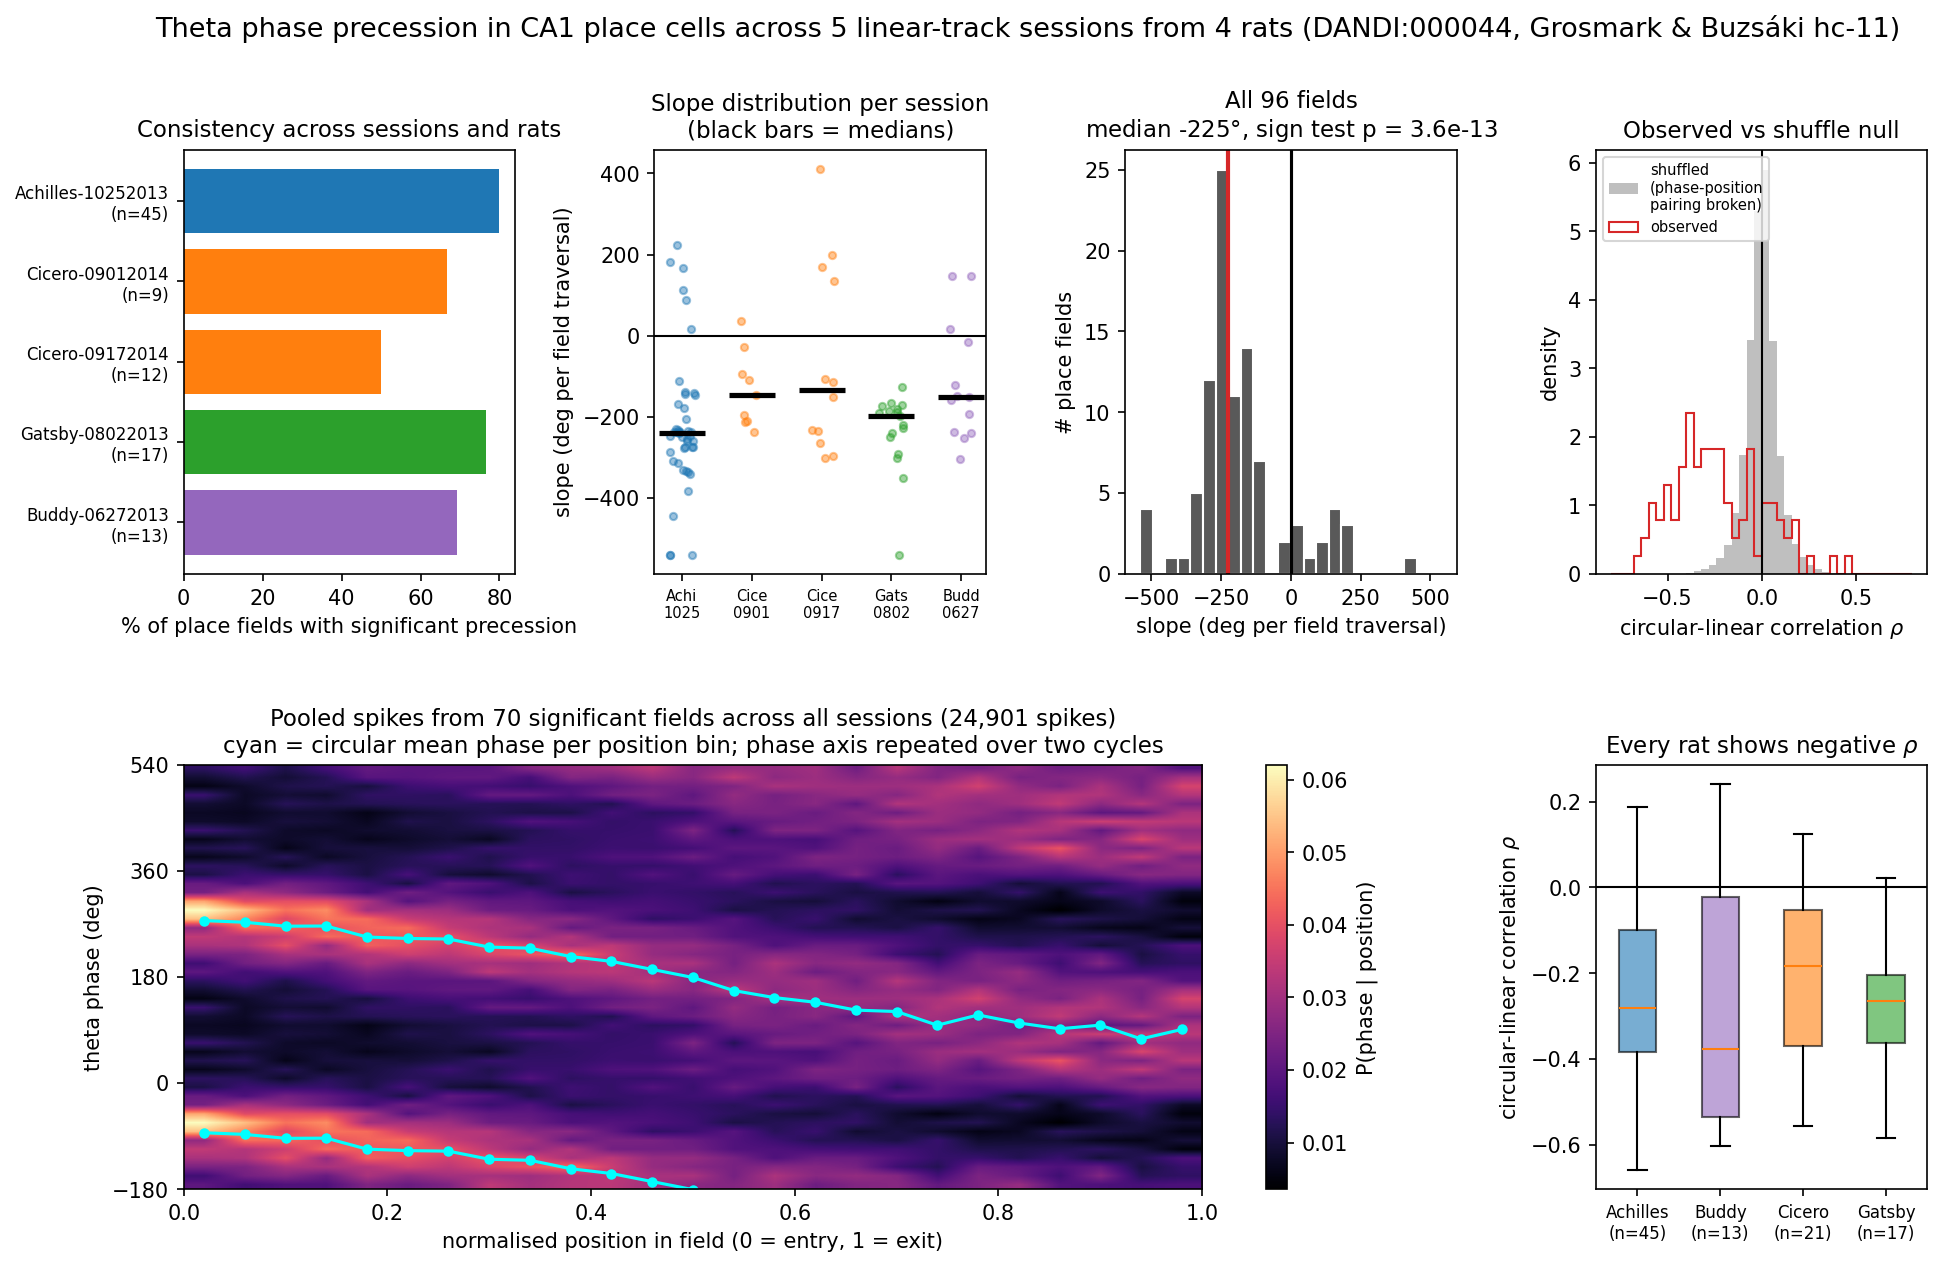

In [15]:
fig = plt.figure(figsize=(15, 9))
gs = GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.42)
colors = {"Achilles": "tab:blue", "Cicero": "tab:orange", "Gatsby": "tab:green",
          "Buddy": "tab:purple"}

g = allpc.groupby("session").apply(
    lambda d: pd.Series({"n": len(d), "frac_sig": (d.pval < 0.05).mean(),
                         "median_slope": d.slope_deg.median()}), include_groups=False)
g = g.loc[LINEAR_SESSIONS]

ax = fig.add_subplot(gs[0, 0])
ax.barh(range(len(g)), g.frac_sig * 100, color=[colors[s.split("-")[0]] for s in g.index])
ax.set_yticks(range(len(g)))
ax.set_yticklabels([f"{s}\n(n={int(n)})" for s, n in zip(g.index, g.n)], fontsize=8)
ax.set_xlabel("% of place fields with significant precession")
ax.set_title("Consistency across sessions and rats")
ax.invert_yaxis()

ax = fig.add_subplot(gs[0, 1])
rng_j = np.random.default_rng(0)
for s, d in allpc.groupby("session"):
    ax.scatter(np.full(len(d), list(g.index).index(s)) + rng_j.uniform(-.18, .18, len(d)),
               d.slope_deg, s=12, alpha=0.45, color=colors[s.split("-")[0]])
ax.plot(range(len(g)), g.median_slope, "k_", ms=22, mew=2.5)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(range(len(g)))
ax.set_xticklabels([s.split("-")[0][:4] + "\n" + s.split("-")[1][:4] for s in g.index],
                   fontsize=7)
ax.set_ylabel("slope (deg per field traversal)")
ax.set_title("Slope distribution per session\n(black bars = medians)")

ax = fig.add_subplot(gs[0, 2])
ax.hist(allpc.slope_deg, bins=np.arange(-540, 570, 45), color="0.35", edgecolor="w")
ax.axvline(0, color="k", lw=1.5)
ax.axvline(allpc.slope_deg.median(), color="tab:red", lw=2)
ax.set_xlabel("slope (deg per field traversal)")
ax.set_ylabel("# place fields")
ax.set_title(f"All {len(allpc)} fields\nmedian {allpc.slope_deg.median():.0f}$\\degree$, "
             f"sign test p = {bt.pvalue:.1e}")

ax = fig.add_subplot(gs[0, 3])
bins_r = np.linspace(-0.8, 0.8, 41)
ax.hist(np.concatenate(nulls), bins=bins_r, density=True, color="0.75",
        label="shuffled\n(phase-position\npairing broken)")
ax.hist(allpc.rho, bins=bins_r, density=True, histtype="step", color="tab:red", lw=2,
        label="observed")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("circular-linear correlation $\\rho$")
ax.set_ylabel("density")
ax.set_title("Observed vs shuffle null")
ax.legend(fontsize=7, loc="upper left")

ax = fig.add_subplot(gs[1, :3])
X = np.concatenate([x for x, _ in pooled_xy])
P = np.degrees(np.concatenate([p for _, p in pooled_xy]))
H, xe, ye = np.histogram2d(np.r_[X, X], np.r_[P, P + 360],
                           bins=[np.linspace(0, 1, 26), np.linspace(-180, 540, 49)])
H = H / H.sum(axis=1, keepdims=True)
im = ax.imshow(H.T, origin="lower", aspect="auto", cmap="magma", extent=[0, 1, -180, 540],
               interpolation="bilinear")
xc = 0.5 * (xe[1:] + xe[:-1])
mp = [np.degrees(np.angle(np.exp(1j * np.radians(P[(X >= xe[i]) & (X < xe[i + 1])])).mean()))
      for i in range(len(xc))]
mp = np.degrees(np.unwrap(np.radians(np.array(mp))))
for off in (-360, 0, 360):
    ax.plot(xc, mp + off, "o-", color="cyan", ms=4, lw=1.5)
ax.set_ylim(-180, 540)
ax.set_xlabel("normalised position in field (0 = entry, 1 = exit)")
ax.set_ylabel("theta phase (deg)")
ax.set_yticks([-180, 0, 180, 360, 540])
ax.set_title(f"Pooled spikes from {len(pooled_xy)} significant fields across all sessions "
             f"({len(X):,} spikes)\ncyan = circular mean phase per position bin; "
             "phase axis repeated over two cycles")
fig.colorbar(im, ax=ax, label="P(phase | position)")

ax = fig.add_subplot(gs[1, 3])
subs = sorted(allpc.subject.unique())
data = [allpc.rho[allpc.subject == s].values for s in subs]
bp = ax.boxplot(data, tick_labels=[f"{s}\n(n={len(d)})" for s, d in zip(subs, data)],
                patch_artist=True, showfliers=False)
for patch, s in zip(bp["boxes"], subs):
    patch.set_facecolor(colors[s])
    patch.set_alpha(0.6)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("circular-linear correlation $\\rho$")
ax.set_title("Every rat shows negative $\\rho$")
ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Theta phase precession in CA1 place cells across 5 linear-track sessions from "
             "4 rats (DANDI:000044, Grosmark & Buzsáki hc-11)", fontsize=13)
fig.savefig("fig07_multisession_summary.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("fig07_multisession_summary.png"))

## Summary

Theta phase precession is present and easy to demonstrate in this dataset. Of the 96 CA1
place fields that met the spatial and sampling criteria across five linear-track sessions
from four rats, 85% had a negative phase-position slope, 73% were individually significant
against a permutation null that preserves both the cell's phase locking and its sampling of
the field, and 66% were both significant and negative (the permutation test is two-sided in
the magnitude of the correlation, so significance on its own does not imply a descending
slope). The median slope of about -225 degrees per field traversal
corresponds to roughly two-thirds of a theta cycle, in the range that the original
descriptions report; the pooled density in figure 7 shows the same descent as a single
continuous band running from about 280 degrees at field entry to about 80 degrees at field
exit. Every rat contributes a negative median correlation, and the observed distribution of
correlations is clearly displaced from the shuffle null.

A few caveats are worth stating. Theta phase is measured from one LFP channel per session,
chosen for its theta-to-delta ratio, and the absolute phase offset therefore depends on
where that channel sat relative to the pyramidal layer; the slope, which is the quantity of
interest here, does not. The place field is defined as the contiguous region above 20% of
the peak rate of the smoothed tuning curve, and fields peaking near the ends of the track
are excluded because they are truncated. The three circular-maze sessions in the dandiset
were not analysed: the linearization for that maze wraps around and does not decompose into
unidirectional traversals under the same simple rule, and adapting it was not necessary to
make the point. Finally, the fraction of significant fields depends on how many spikes each
field contributes, so it should be read as a property of this dataset and these criteria
rather than as a biological constant. Four fields out of 96 had a fitted slope that ran
into the edge of the +/- 1.5 cycle search range; two of those still had a clearly negative
correlation and two did not, and they are left in the tallies rather than removed by hand.

### References

- O'Keefe J, Recce ML (1993). Phase relationship between hippocampal place units and the
  EEG theta rhythm. *Hippocampus* 3:317-330.
- Grosmark AD, Buzsáki G (2016). Diversity in neural firing dynamics supports both rigid
  and learned hippocampal sequences. *Science* 351:1440-1443.
- Kempter R, Leibold C, Buzsáki G, Diba K, Schmidt R (2012). Quantifying circular-linear
  associations: hippocampal phase precession. *J Neurosci Methods* 207:113-124.